## ===============================
## Resumo do que foi implementado
## ==============================

Organizei duas frentes principais:

1. **DVOL BTC diário (2021–2025)**  
   - Leitura e tratamento do CSV com histórico do DVOL da Deribit.  
   - Conversão da coluna de data para `datetime` e ordenação da série no tempo.  
   - Definição do nível diário do DVOL usando o `close` (em %) e criação da versão em decimal (`dvol = dvol_pct / 100`).  
   - Gráfico do histórico do DVOL, já formatado para visualização de regimes ao longo do tempo.

2. **Pipeline de volatilidade implícita por strike e vencimento (superfície instantânea)**  
   - Conexão com a API pública da Deribit (`/public/get_instruments` e `/public/ticker`).  
   - Coleta de todos os contratos de opções de BTC (calls e puts), com organização em DataFrame contendo `instrument_name`, `strike`, `expiration` e `option_type`.  
   - Seleção de um vencimento específico (ajustável) para análise detalhada.  
   - Extração da volatilidade implícita (`mark_iv`) de cada contrato desse vencimento e padronização da IV (em % e em decimal).  
   - Construção do *smile* de volatilidade (IV × strike) para esse vencimento.  
   - Cálculo de um skew simples, comparando a IV média de puts OTM (strikes abaixo do ATM) com a IV média de calls OTM (strikes acima do ATM).

A ideia é que:

- a parte do DVOL sirva diretamente como base para os cálculos de IV30/BVRP, substituindo a dependência da API que só retornava dados até 2023;  
- a parte de smile/skew funcione como uma extensão potencial para análise de regimes e condição de mercado, adicionando informação microestrutural do mercado de opções ao uso do DVOL agregado.

Fica à vontade para adaptar os critérios de seleção de vencimento, moneyness e métrica de skew conforme a necessidade do modelo e da tese.```


---

### ==================================
### Leitura e tratamento do DVOL (BTC)
### ==================================

Carrego o CSV com o histórico do DVOL da Deribit, converto a coluna de data para formato datetime, ordeno a série no tempo e padronizo o índice:  
uso o **close** como nível diário do DVOL (em %) e também crio a versão em **decimal** (`dvol = dvol_pct / 100`) para usar depois em cálculos como o BVRP.

Agora a série DVOL chama-se df_dvol, não mais df.
Vamos usar df_dvol no merge com o BTC.


In [201]:
#celula 1 - carregar dados#
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("data/vrp_30d_dataset.csv")
df_final["date"] = pd.to_datetime(df_final["date"])

print("Shape:", df_final.shape)
df_final.head()

Shape: (643, 6)


,date,close,ret,rv_30d,iv_30d,vrp_30d
0,2023-02-27,23492.09,-0.002668,52.180368,50.44,-1.740368
1,2023-02-28,23141.57,-0.015033,51.292610,50.37,-0.922610
2,2023-04-01,28452.73,0.206614,87.224138,58.17,-29.054138
3,2023-04-02,28171.87,-0.009920,87.403177,60.28,-27.123177
4,2023-04-03,27800.00,-0.013288,87.380827,61.83,-25.550827


In [202]:
#celula 2 - checagem # 
print(df_final[["iv_30d", "rv_30d", "vrp_30d"]].describe())

           iv_30d      rv_30d     vrp_30d
count  643.000000  643.000000  643.000000
mean    53.246485   47.601708    5.644777
std      9.689334   14.629131   11.524499
min     32.380000   16.756112  -32.405652
25%     47.035000   38.013297    0.421424
50%     53.960000   45.368718    7.209101
75%     58.125000   53.997889   13.042197
max     83.020000   87.430263   28.355131


In [ ]:
# celula 3 - grafico de series temporais (eixo duplo)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_final['date'], df_final['rv_30d'], color='steelblue', linewidth=1.2,
         label='Vol. Realizada 30D (RV30D)')
ax1.plot(df_final['date'], df_final['iv_30d'], color='darkorange', linewidth=1.2,
         label='Vol. Implicita 30D (IV30D - DVOL)')
ax1.set_xlabel('Data')
ax1.set_ylabel('Volatilidade (% a.a.)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_final['date'], df_final['vrp_30d'], color='steelblue', linewidth=1.0,
         linestyle='--', alpha=0.7, label='VRP 30D (IV30D - RV30D)')
ax2.set_ylabel('VRP 30D (p.p. de vol.)')
ax2.axhline(0, color='gray', linewidth=0.7, linestyle=':')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

os.makedirs('../figs/cap3', exist_ok=True)
fig.tight_layout()
fig.savefig('../figs/cap3/vrp_timeseries.png', dpi=300, bbox_inches='tight')
print('Salvo em: ../figs/cap3/vrp_timeseries.png')
plt.show()


In [ ]:
# celula 4 - histograma e KDE do VRP
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig, ax = plt.subplots(figsize=(8, 5))
vrp = df_final['vrp_30d'].dropna()
sns.histplot(vrp, bins=40, kde=True, stat='density', alpha=0.6,
             color='steelblue', ax=ax)
media = vrp.mean()
ax.axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f} p.p.')
ax.set_xlabel('VRP 30D (p.p. de volatilidade)')
ax.set_ylabel('Densidade')
ax.legend()
ax.grid(True, alpha=0.3)

os.makedirs('../figs/cap3', exist_ok=True)
fig.tight_layout()
fig.savefig('../figs/cap3/vrp_histogram_kde.png', dpi=300, bbox_inches='tight')
print('Salvo em: ../figs/cap3/vrp_histogram_kde.png')
plt.show()


In [ ]:
# celula 5 - boxplot do VRP
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_final, x='vrp_30d', color='lightgray',
            fliersize=3, linewidth=1, ax=ax)
ax.set_xlabel('VRP 30D (p.p. de vol.)')
ax.grid(True, axis='x', alpha=0.4)

os.makedirs('../figs/cap3', exist_ok=True)
fig.tight_layout()
fig.savefig('../figs/cap3/vrp_boxplot.png', dpi=300, bbox_inches='tight')
print('Salvo em: ../figs/cap3/vrp_boxplot.png')
plt.show()


In [ ]:
# (removido - save redundante)


In [ ]:


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1) Definir pastas de dados e figuras, relativas ao notebook em /code
DATA_DIR = os.path.join("..", "data")
FIGS_DIR = os.path.join("..", "figs")

# Garante que a pasta de figuras exista (data já existe com os CSVs)
os.makedirs(FIGS_DIR, exist_ok=True)

# 2) Caminho correto para o arquivo DVOL (um nível acima, na pasta /data)
DVOL_PATH = os.path.join(DATA_DIR, "DeriBit_volatility_OHLC_BTC.csv")
print("Lendo arquivo DVOL de:", DVOL_PATH)

# 3) Leitura do DVOL
df_dvol = pd.read_csv(DVOL_PATH, skiprows=1)

# 4) Tratamento básico de datas e ordenação
df_dvol["date"] = pd.to_datetime(df_dvol["date"])
df_dvol = df_dvol.sort_values("date").reset_index(drop=True)

# 5) DVOL diário (em %) e em decimal
df_dvol["dvol_pct"] = df_dvol["close"].astype(float)
df_dvol["dvol"] = df_dvol["dvol_pct"] / 100

# 6) Ver primeiras linhas para conferir
df_dvol.head()


Lendo arquivo DVOL de: ..\data\DeriBit_volatility_OHLC_BTC.csv


,date,symbol,open,high,low,close,dvol_pct,dvol
0,2021-03-24,BTC,84.80,95.94,80.52,95.04,95.04,0.9504
1,2021-03-25,BTC,95.03,97.43,87.25,89.74,89.74,0.8974
2,2021-03-26,BTC,89.74,89.74,80.22,84.52,84.52,0.8452
3,2021-03-27,BTC,84.52,84.60,77.81,79.69,79.69,0.7969
4,2021-03-28,BTC,79.69,81.28,78.20,79.07,79.07,0.7907


In [195]:
df_dvol.head()




,date,symbol,open,high,low,close,dvol_pct,dvol
0,2021-03-24,BTC,84.80,95.94,80.52,95.04,95.04,0.9504
1,2021-03-25,BTC,95.03,97.43,87.25,89.74,89.74,0.8974
2,2021-03-26,BTC,89.74,89.74,80.22,84.52,84.52,0.8452
3,2021-03-27,BTC,84.52,84.60,77.81,79.69,79.69,0.7969
4,2021-03-28,BTC,79.69,81.28,78.20,79.07,79.07,0.7907


---

### =================================
### Visualização do histórico do DVOL
### =================================

Aqui estou plotando a série histórica do DVOL (BTC) usando o valor de **fechamento diário**.  
O gráfico usa escala em porcentagem (%) e formata o eixo de datas por ano para facilitar a leitura e visualização dos regimes de volatilidade ao longo do tempo.```


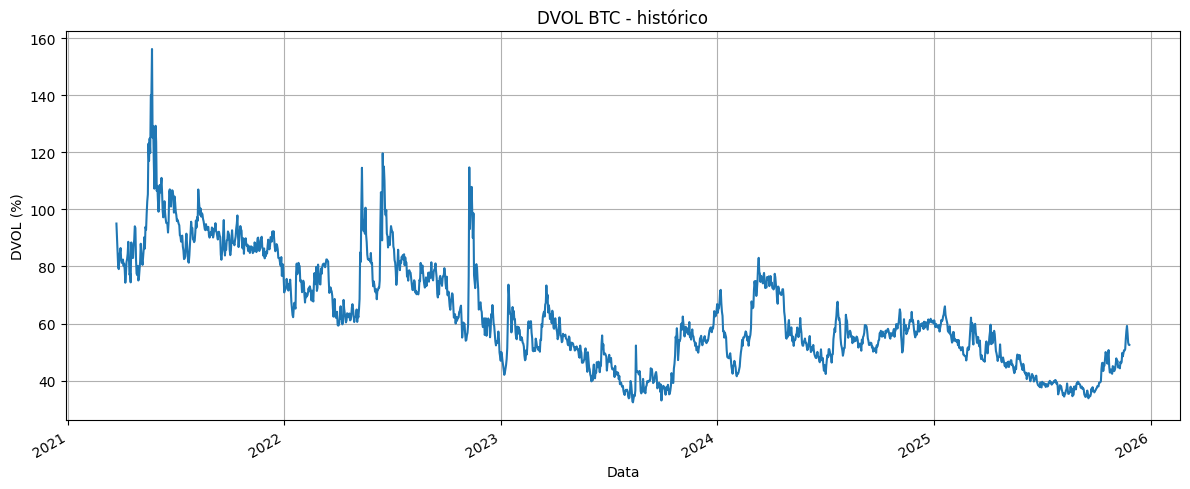

In [196]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))  # aumenta largura e altura

plt.plot(df_dvol["date"], df_dvol["dvol_pct"])
plt.xlabel("Data")
plt.ylabel("DVOL (%)")
plt.title("DVOL BTC - histórico")

# deixa as datas legíveis

plt.gca().xaxis.set_major_locator(mdates.YearLocator())   # marca 1 vez por ano
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()  # gira os rótulos

plt.grid(True)             # gradezinha pra ajudar a ver
plt.tight_layout()         # ajusta tudo pra não cortar nada
plt.show()
plt.savefig("figs/dvol_btc_historico.png", dpi=300, bbox_inches="tight")
plt.close()  #Até aqui, você tem DVOL limpinho + gráfico

---

In [197]:
import os

print("btc_path exists?", os.path.exists("data/btc_prices.csv"))
print(os.listdir("data"))


btc_path exists? True
['btc_prices.csv', 'dataset_bvrp_full.csv', 'dataset_bvrp_with_skew.csv', 'DeriBit_volatility_OHLC_BTC.csv', 'dvol_30d_deribit.csv', 'dvol_30d_full.csv', 'estatisticas_retornos_futuros.csv', 'estatisticas_vrp_30d.csv', 'iv_smile_snapshot.csv', 'iv_smile_snapshot_with_skew.csv', 'ml_dataset.csv', 'options_snapshot.csv', 'rf_feature_importance.csv', 'rf_gridsearch_feature_importance.csv', 'skew_history.csv', 'tabela_cap4_estatisticas_completas.csv', 'tabela_cap4_estatisticas_completas.tex', 'tabela_estatisticas_principais.csv', 'tabela_estatisticas_principais.tex', 'tabela_estatisticas_retornos_futuros.tex', 'tabela_estatisticas_vrp_30d.tex', 'vrp_30d_dataset.csv', 'vrp_regime_stats.csv', 'vrp_with_regimes.csv', 'vrp_with_targets.csv', 'xgb_feature_importance.csv']


In [198]:
import os
print("WORKING DIR =", os.getcwd())


WORKING DIR = c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code


In [199]:
#Passo 3 – Inserir o PIPELINE BVRP logo DEPOIS do gráfico do DVOL
#3.1 – Carregar BTC e fazer merge com DVOL

         date  btc_close  iv_30d
0  2021-03-24   52303.65   95.04
1  2021-03-25   51293.78   89.74
2  2021-03-26   55025.59   84.52
3  2021-03-27   55817.14   79.69
4  2021-03-28   55777.63   79.07


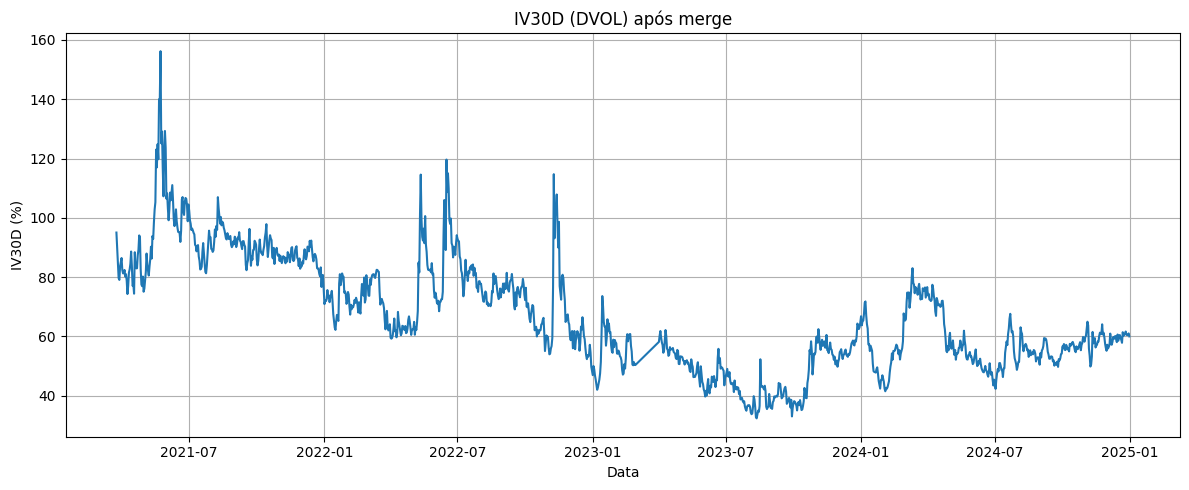

In [200]:
# ================================
# 1) CARREGA BTC E FAZ MERGE COM DVOL
# ================================

btc_path = os.path.join("data", "btc_prices.csv")
df_btc = pd.read_csv(btc_path)

df_btc.columns = [c.lower() for c in df_btc.columns]
assert "date" in df_btc.columns, "btc_prices.csv precisa ter coluna 'date'"
assert "close" in df_btc.columns, "btc_prices.csv precisa ter coluna 'close'"

df_btc["date"] = pd.to_datetime(df_btc["date"]).dt.date
df_btc = df_btc.sort_values("date").reset_index(drop=True)
df_btc.rename(columns={"close": "btc_close"}, inplace=True)

# Prepara DVOL (IV30D)
df_dvol_merged = df_dvol.copy()
df_dvol_merged["date"] = df_dvol_merged["date"].dt.date
df_dvol_merged.rename(columns={"dvol_pct": "iv_30d"}, inplace=True)

# Merge BTC + DVOL
df = pd.merge(df_btc, df_dvol_merged[["date", "iv_30d"]], on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)

print(df.head())

# GRÁFICO
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["iv_30d"])
plt.title("IV30D (DVOL) após merge")
plt.xlabel("Data")
plt.ylabel("IV30D (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3.2 – Retornos log e volatilidade realizada (RV7/14/30/60)
# ---------------------------------------------------------
# Este bloco:
# 1) Garante que 'btc_close' é numérico
# 2) Calcula retornos logarítmicos diários
# 3) Define uma função para volatilidade realizada anualizada
# 4) Calcula RV para janelas de 7, 14, 30 e 60 dias
# 5) Mostra uma prévia em tabela
# 6) (Opcional) Plota a RV30D ao longo do tempo
# Gráfico 2×2 das RVs com linhas de eventos
# Histogramas das RVs
# Matriz de correlação (heatmap simples)
# Comparação DVOL (IV30D) × RV30D
# Cálculo e gráfico da VRP30D = IV30D – RV30D



Prévia das colunas calculadas:
          date  btc_close       ret     rv_7d    rv_14d    rv_30d    rv_60d
60  2021-05-23   34655.25 -0.077550  4.336058  5.241384  6.184640  6.916790
61  2021-05-24   38796.29  0.112875  4.684090  5.609144  6.537173  7.235582
62  2021-05-25   38324.72 -0.012230  4.680022  5.606510  6.530403  7.113932
63  2021-05-26   39241.91  0.023650  3.649068  5.021668  6.284787  7.123041
64  2021-05-27   38529.98 -0.018309  3.134945  5.033813  6.284538  7.131612


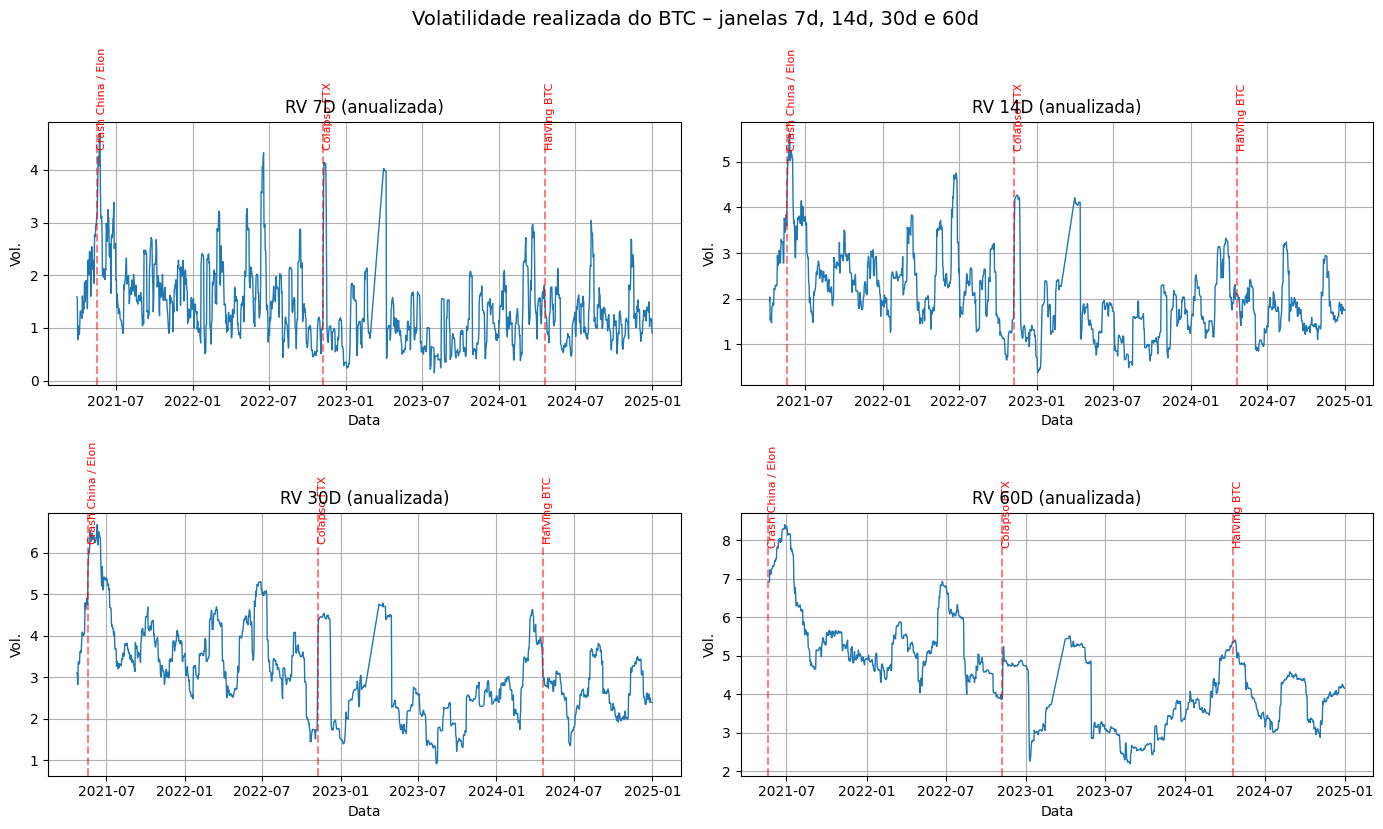

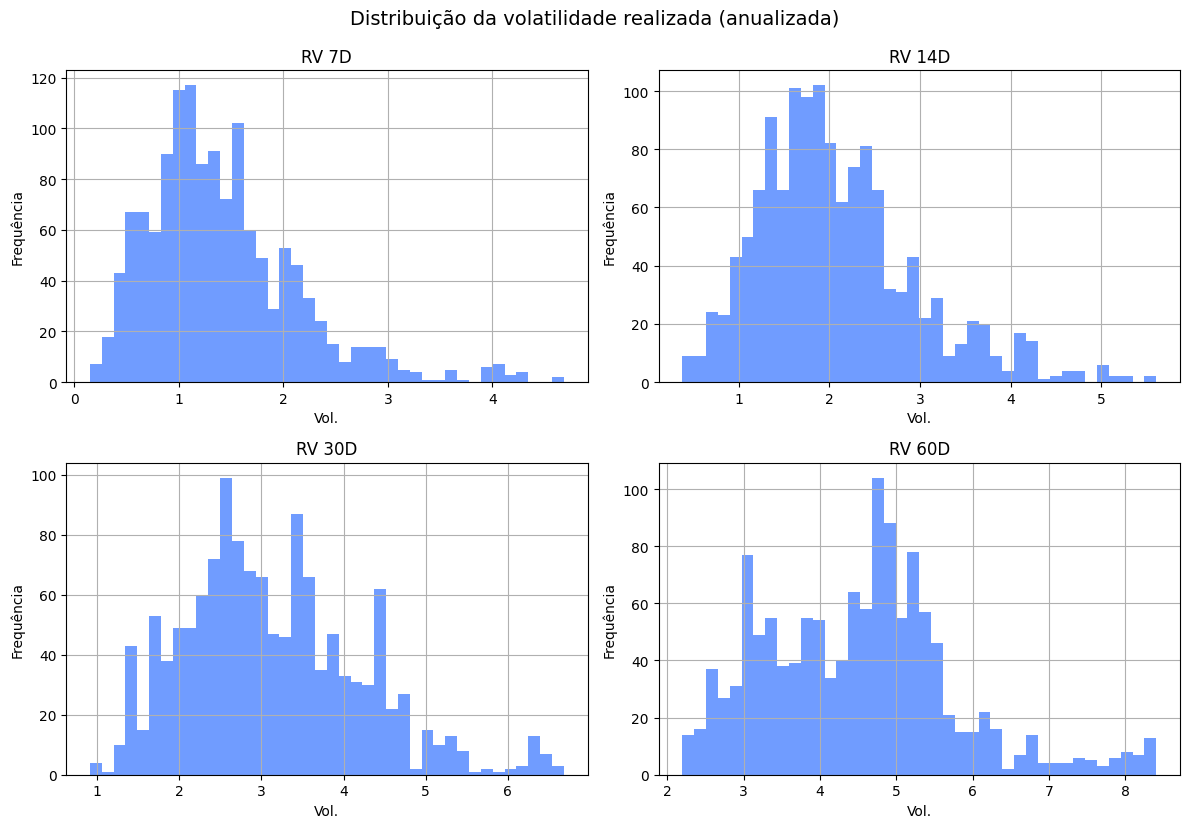

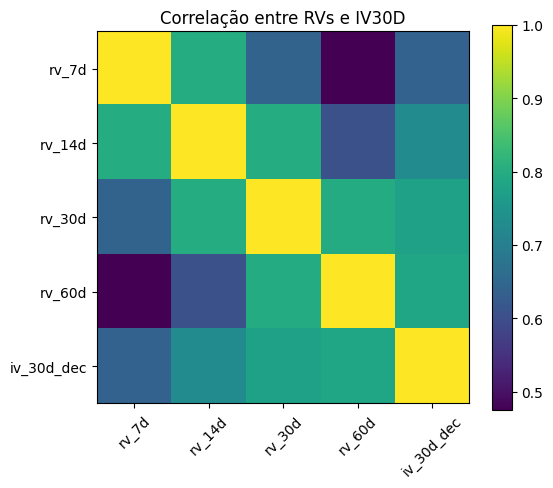


Matriz de correlação:
               rv_7d    rv_14d    rv_30d    rv_60d  iv_30d_dec
rv_7d       1.000000  0.800877  0.641381  0.475008    0.640063
rv_14d      0.800877  1.000000  0.800156  0.604555    0.728966
rv_30d      0.641381  0.800156  1.000000  0.798128    0.775105
rv_60d      0.475008  0.604555  0.798128  1.000000    0.782839
iv_30d_dec  0.640063  0.728966  0.775105  0.782839    1.000000


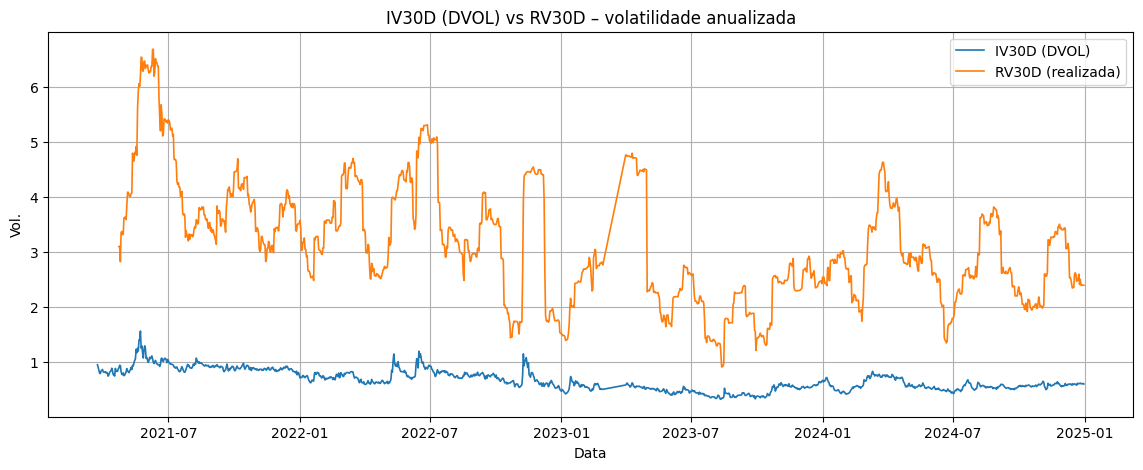

In [154]:
# ============================================================
# 3.2 — Retornos log e volatilidade realizada (RV7/14/30/60)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1) Garantir que 'btc_close' está numérico e calcular retornos log
# ------------------------------------------------------------

df["btc_close"] = df["btc_close"].astype(float)
df["ret"] = np.log(df["btc_close"] / df["btc_close"].shift(1))


# ------------------------------------------------------------
# 2) Função para calcular volatilidade realizada anualizada
#    RV = sqrt( 365 * soma(retornos² na janela) )
# ------------------------------------------------------------

def realized_vol(returns, window):
    return np.sqrt(365 * returns.rolling(window).apply(lambda x: np.sum(x**2), raw=True))


# ------------------------------------------------------------
# 3) Calcular RVs nas janelas de 7, 14, 30 e 60 dias
# ------------------------------------------------------------

df["rv_7d"]  = realized_vol(df["ret"], 7)
df["rv_14d"] = realized_vol(df["ret"], 14)
df["rv_30d"] = realized_vol(df["ret"], 30)
df["rv_60d"] = realized_vol(df["ret"], 60)

print("\nPrévia das colunas calculadas:")
print(df[["date", "btc_close", "ret", "rv_7d", "rv_14d", "rv_30d", "rv_60d"]].dropna().head())


# ------------------------------------------------------------
# 4) Gráficos de RV com eventos históricos
# ------------------------------------------------------------

eventos = {
    "Crash China / Elon": "2021-05-19",
    "Colapso FTX":        "2022-11-08",
    "Halving BTC":        "2024-04-20"
}

series_info = [
    ("rv_7d",  "RV 7D (anualizada)"),
    ("rv_14d", "RV 14D (anualizada)"),
    ("rv_30d", "RV 30D (anualizada)"),
    ("rv_60d", "RV 60D (anualizada)")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, titulo) in zip(axes, series_info):
    ax.plot(df["date"], df[col], linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel("Data")
    ax.set_ylabel("Vol.")
    ax.grid(True)

    # Adicionar eventos históricos
    for nome, data in eventos.items():
        ax.axvline(pd.to_datetime(data), color="red", linestyle="--", alpha=0.5)
        ax.text(pd.to_datetime(data), ax.get_ylim()[1] * 0.9, nome,
                rotation=90, color="red", fontsize=8)

plt.tight_layout()
plt.suptitle("Volatilidade realizada do BTC – janelas 7d, 14d, 30d e 60d",
             fontsize=14, y=1.03)
plt.show()


# ------------------------------------------------------------
# 5) Histogramas das distribuições das RVs
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, titulo) in zip(axes, series_info):
    ax.hist(df[col].dropna(), bins=40, color="#4C84FF", alpha=0.8)
    ax.set_title(titulo.replace("(anualizada)", "").strip())
    ax.set_xlabel("Vol.")
    ax.set_ylabel("Frequência")
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Distribuição da volatilidade realizada (anualizada)", fontsize=14, y=1.03)
plt.show()


# ------------------------------------------------------------
# 6) Correlação entre RVs e IV30D
# ------------------------------------------------------------

df["iv_30d_dec"] = df["iv_30d"] / 100   # converter DVOL para decimal se necessário

corr_cols = ["rv_7d", "rv_14d", "rv_30d", "rv_60d", "iv_30d_dec"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap="viridis", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlação entre RVs e IV30D")
plt.show()

print("\nMatriz de correlação:")
print(corr_matrix)


# ------------------------------------------------------------
# 7) Comparação IV30D vs RV30D
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["iv_30d_dec"], label="IV30D (DVOL)", linewidth=1.2)
plt.plot(df["date"], df["rv_30d"], label="RV30D (realizada)", linewidth=1.2)
plt.xlabel("Data")
plt.ylabel("Vol.")
plt.title("IV30D (DVOL) vs RV30D – volatilidade anualizada")
plt.legend()
plt.grid(True)
plt.show()



Prévia de IV30D, RV30D e VRP30D:
          date  iv_30d  iv_30d_dec    rv_30d  vrp_30d_pts  vrp_30d_pct
30  2021-04-23   89.31      0.8931  3.097129    -2.204029  -220.402873
31  2021-04-24   94.08      0.9408  3.101453    -2.160653  -216.065336
32  2021-04-25   93.46      0.9346  2.821676    -1.887076  -188.707599
33  2021-04-26   82.66      0.8266  3.352488    -2.525888  -252.588835
34  2021-04-27   77.53      0.7753  3.371123    -2.595823  -259.582308


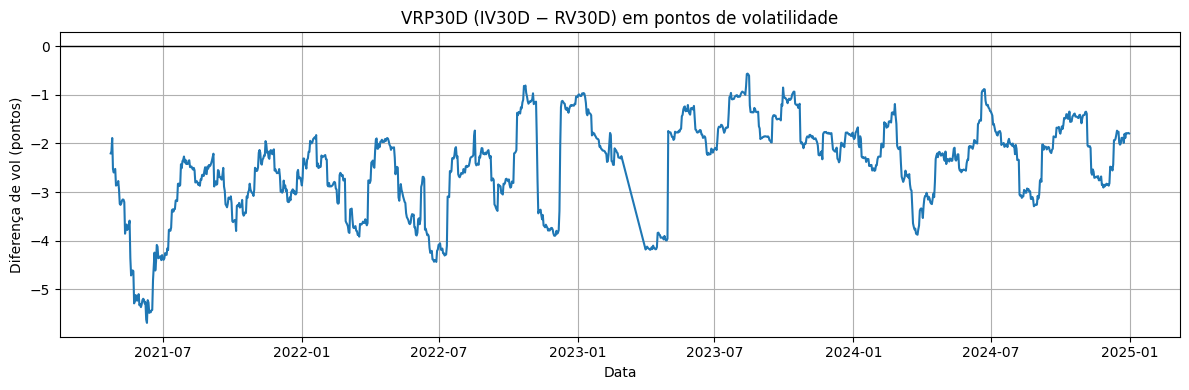

In [155]:
# =====================================
# 3.3 – VRP (BVRP) = IV30D − RV30D
# =====================================

# 1) Garante que temos a IV em decimal (0.80 = 80%)
#    Aqui assumimos que 'iv_30d' está em porcentagem (ex: 80 = 80%)
df["iv_30d_dec"] = df["iv_30d"] / 100.0

# 2) VRP em "pontos de volatilidade" (decimal, ex: 0.5 = 50 p.p. de vol)
df["vrp_30d_pts"] = df["iv_30d_dec"] - df["rv_30d"]

# 3) Versão em percentual (apenas multiplicando por 100)
df["vrp_30d_pct"] = df["vrp_30d_pts"] * 100

# 4) Prévia dos dados (opcional)
print("\nPrévia de IV30D, RV30D e VRP30D:")
print(
    df[
        [
            "date",
            "iv_30d",       # IV em %
            "iv_30d_dec",   # IV em decimal
            "rv_30d",       # RV em decimal
            "vrp_30d_pts",  # VRP em pontos de vol
            "vrp_30d_pct"   # VRP em %
        ]
    ].dropna().head()
)

# 5) Gráfico do VRP em pontos de volatilidade
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["vrp_30d_pts"])
plt.axhline(0, color="black", linewidth=1)
plt.title("VRP30D (IV30D − RV30D) em pontos de volatilidade")
plt.xlabel("Data")
plt.ylabel("Diferença de vol (pontos)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [156]:
# ============================================================
# 3.4 – Retornos futuros (1, 5, 10, 20, 30, 60 dias)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 3.4.1 Cálculo dos retornos futuros em vários horizontes
# ------------------------------------------------------------

horizons = [1, 5, 10, 20, 30, 60]

for h in horizons:
    col_name = f"ret_fut_{h}d"
    # Retorno log do preço de hoje até h dias à frente
    df[col_name] = np.log(df["btc_close"].shift(-h) / df["btc_close"])

# Criamos uma versão "clean" apenas com linhas em que
# TODOS os retornos futuros estão disponíveis
ret_fut_cols = [f"ret_fut_{h}d" for h in horizons]
df_ret_fut = df.dropna(subset=ret_fut_cols).reset_index(drop=True)

print("\nPrévia dos retornos futuros (log):")
print(df_ret_fut[["date"] + ret_fut_cols].head())


Prévia dos retornos futuros (log):
         date  ret_fut_1d  ret_fut_5d  ret_fut_10d  ret_fut_20d  ret_fut_30d  \
0  2021-03-24   -0.019497    0.097072     0.086896     0.195154    -0.022790   
1  2021-03-25    0.070229    0.135663     0.126350     0.204923    -0.024590   
2  2021-03-26    0.014283    0.065332     0.071940     0.137873    -0.114616   
3  2021-03-27   -0.000708    0.050707     0.038209     0.094266    -0.033071   
4  2021-03-28    0.032765    0.055317     0.003147     0.073083    -0.013822   

   ret_fut_60d  
0    -0.411617  
1    -0.279245  
2    -0.361703  
3    -0.352336  
4    -0.369936  



Estatísticas descritivas dos retornos futuros (log):
H =  1 dias → vol anualizada ≈ 0.61
H =  5 dias → vol anualizada ≈ 0.60
H = 10 dias → vol anualizada ≈ 0.60
H = 20 dias → vol anualizada ≈ 0.61
H = 30 dias → vol anualizada ≈ 0.62
H = 60 dias → vol anualizada ≈ 0.66

Teste de normalidade Jarque-Bera para os retornos futuros:
H =  1 dias → JB = 1086.89, p-valor = 0.0000
H =  5 dias → JB = 269.61, p-valor = 0.0000
H = 10 dias → JB = 290.78, p-valor = 0.0000
H = 20 dias → JB = 38.11, p-valor = 0.0000
H = 30 dias → JB = 1.72, p-valor = 0.4228
H = 60 dias → JB = 26.27, p-valor = 0.0000

(Em geral, p-valor muito baixo rejeita normalidade.)


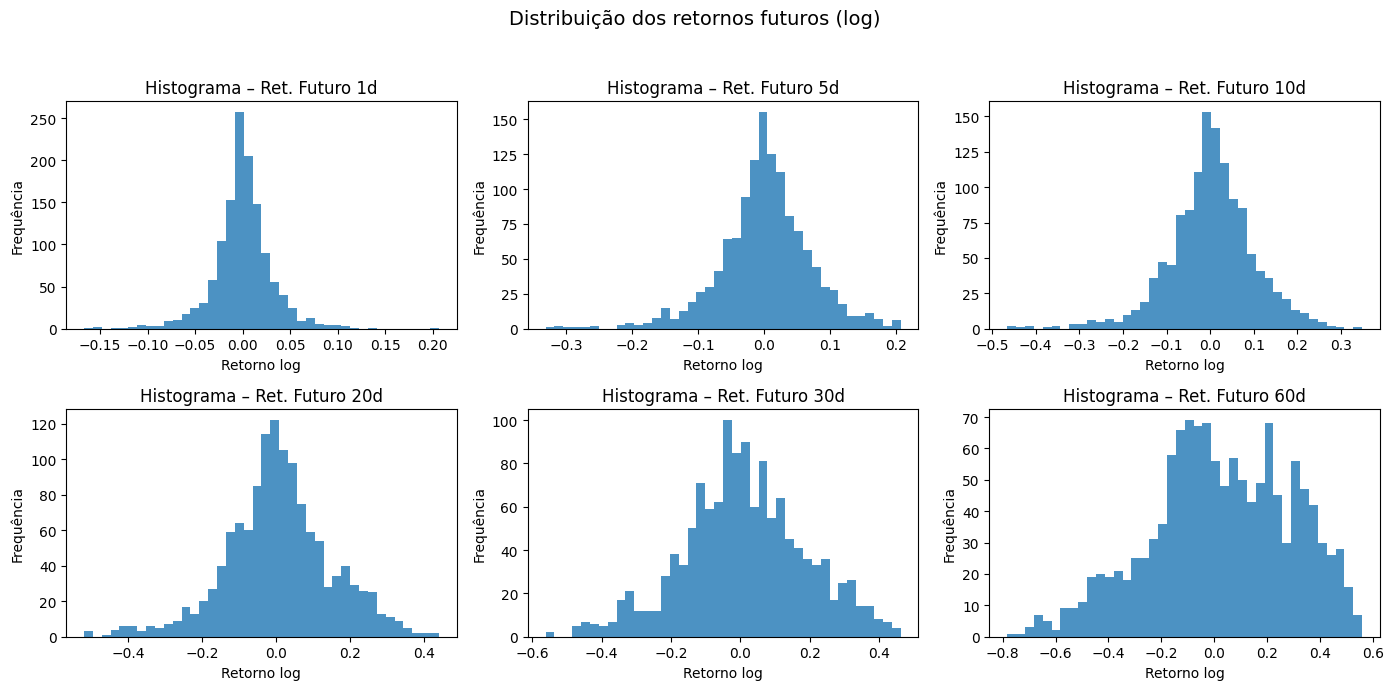

C:\Users\EM2024006937\AppData\Local\Temp\ipykernel_32468\3201894462.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=horizons, showfliers=True)


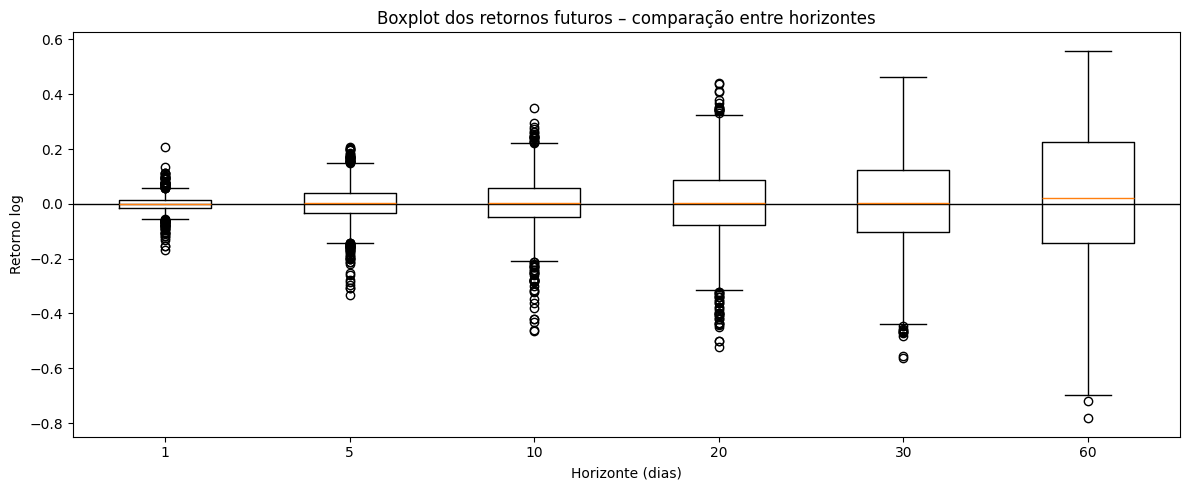

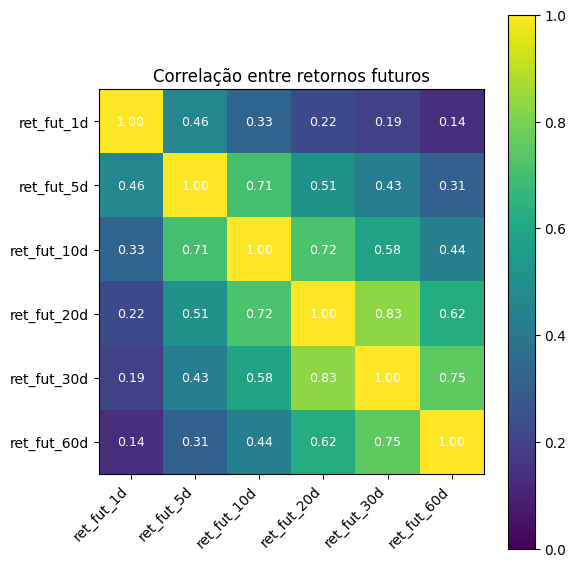

In [157]:
# ------------------------------------------------------------
# 3.4.2 Estatísticas descritivas e volatilidade anualizada
# ------------------------------------------------------------

print("\nEstatísticas descritivas dos retornos futuros (log):")
desc = df_ret_fut[ret_fut_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
# print(desc)

# print("\nVolatilidade anualizada dos retornos futuros por horizonte:")
for h in horizons:
    col = f"ret_fut_{h}d"
    # std do retorno de h dias → anualiza multiplicando por sqrt(365/h)
    vol_ann = df_ret_fut[col].std() * np.sqrt(365 / h)
    print(f"H = {h:2d} dias → vol anualizada ≈ {vol_ann:.2f}")

# ------------------------------------------------------------
# 3.4.3 Teste de normalidade (Jarque-Bera)
# ------------------------------------------------------------
# Obs.: se der erro de ImportError, instale:
#       pip install scipy

try:
    from scipy.stats import jarque_bera

    print("\nTeste de normalidade Jarque-Bera para os retornos futuros:")
    for h in horizons:
        col = f"ret_fut_{h}d"
        jb_stat, jb_p = jarque_bera(df_ret_fut[col])
        print(f"H = {h:2d} dias → JB = {jb_stat:.2f}, p-valor = {jb_p:.4f}")

    print("\n(Em geral, p-valor muito baixo rejeita normalidade.)")

except ImportError:
    print(
        "\n[AVISO] SciPy não está instalado. "
        "Pulei o teste Jarque-Bera. "
        "Para rodar, instale com: pip install scipy"
    )


# ------------------------------------------------------------
# 3.4.4 Histogramas dos retornos futuros
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Distribuição dos retornos futuros (log)", fontsize=14)

for ax, h in zip(axes.flatten(), horizons):
    col = f"ret_fut_{h}d"
    ax.hist(df_ret_fut[col], bins=40, alpha=0.8)
    ax.set_title(f"Histograma – Ret. Futuro {h}d")
    ax.set_xlabel("Retorno log")
    ax.set_ylabel("Frequência")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ------------------------------------------------------------
# 3.4.5 Boxplot comparando horizontes
# ------------------------------------------------------------

data_box = [df_ret_fut[f"ret_fut_{h}d"] for h in horizons]

plt.figure(figsize=(12, 5))
plt.boxplot(data_box, labels=horizons, showfliers=True)
plt.axhline(0, color="black", linewidth=1)
plt.title("Boxplot dos retornos futuros – comparação entre horizontes")
plt.xlabel("Horizonte (dias)")
plt.ylabel("Retorno log")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.4.6 Heatmap de correlação entre retornos futuros
# ------------------------------------------------------------

corr_mat = df_ret_fut[ret_fut_cols].corr()

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(corr_mat, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(len(ret_fut_cols)))
ax.set_yticks(range(len(ret_fut_cols)))
ax.set_xticklabels(ret_fut_cols, rotation=45, ha="right")
ax.set_yticklabels(ret_fut_cols)

for i in range(len(ret_fut_cols)):
    for j in range(len(ret_fut_cols)):
        value = corr_mat.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center", color="white", fontsize=9
        )

plt.title("Correlação entre retornos futuros")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# (Opcional) atualizar df principal para uso nos próximos passos
# ------------------------------------------------------------
# Se você quiser que o df principal já fique "limpo" e com
# os retornos futuros consistentes, pode fazer:
df = df_ret_fut.copy()


✅ DATASET FINAL salvo em: data\dataset_bvrp_full.csv
Shape: (1288, 16)
         date  btc_close       ret  rv_7d  rv_14d  rv_30d  rv_60d  iv_30d  \
0  2021-03-24   52303.65       NaN    NaN     NaN     NaN     NaN   95.04   
1  2021-03-25   51293.78 -0.019497    NaN     NaN     NaN     NaN   89.74   
2  2021-03-26   55025.59  0.070229    NaN     NaN     NaN     NaN   84.52   
3  2021-03-27   55817.14  0.014283    NaN     NaN     NaN     NaN   79.69   
4  2021-03-28   55777.63 -0.000708    NaN     NaN     NaN     NaN   79.07   

   iv_30d_dec  vrp_30d  ret_fut_1d  ret_fut_5d  ret_fut_10d  ret_fut_20d  \
0      0.9504      NaN   -0.019497    0.097072     0.086896     0.195154   
1      0.8974      NaN    0.070229    0.135663     0.126350     0.204923   
2      0.8452      NaN    0.014283    0.065332     0.071940     0.137873   
3      0.7969      NaN   -0.000708    0.050707     0.038209     0.094266   
4      0.7907      NaN    0.032765    0.055317     0.003147     0.073083   

   ret_f

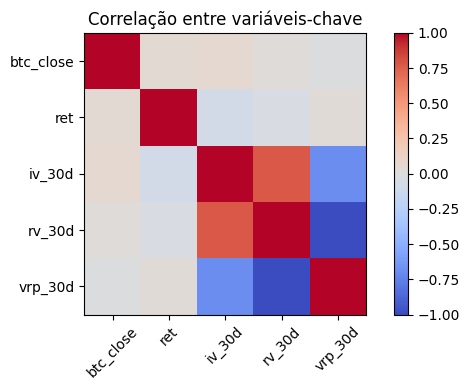

In [158]:
# =========================================
# 3.5 Dataset final consolidado e exportação para CSV
# =========================================

# Se por acaso ainda não existir vrp_30d, recalcula aqui
if "vrp_30d" not in df.columns:
    if {"iv_30d_dec", "rv_30d"}.issubset(df.columns):
        df["vrp_30d"] = df["iv_30d_dec"] - df["rv_30d"]
        # print("ℹ️ vrp_30d não encontrada em df – recalculada como iv_30d_dec − rv_30d.")
    else:
        # Se quiser pode trocar por raise ValueError(...)
        print("⚠️ Não foi possível criar vrp_30d (faltam iv_30d_dec ou rv_30d).")

cols_final = [
    "date",
    "btc_close",
    "ret",

    # volatilidades realizadas
    "rv_7d", "rv_14d", "rv_30d", "rv_60d",

    # volatilidade implícita
    "iv_30d",
    "iv_30d_dec",

    # VRP
    "vrp_30d",
]

# adiciona automaticamente todos os retornos futuros
cols_final += [c for c in df.columns if c.startswith("ret_fut_")]

# se houver coluna de regime, incluir
if "regime" in df.columns:
    cols_final.append("regime")

# separa colunas existentes e ausentes
cols_existentes = [c for c in cols_final if c in df.columns]
cols_ausentes   = [c for c in cols_final if c not in df.columns]

if cols_ausentes:
    print("⚠️ Aviso: as seguintes colunas não foram encontradas em df e ficarão fora do dataset final:")
    print(cols_ausentes)

df_final = df[cols_existentes].copy()

out_path = os.path.join("data", "dataset_bvrp_full.csv")
df_final.to_csv(out_path, index=False)

print("\n✅ DATASET FINAL salvo em:", out_path)
print("Shape:", df_final.shape)
print(df_final.head())

print("\n=== CHECK 1: NaNs por coluna ===")
print(df_final.isna().sum())

print("\n=== CHECK 2: Estatísticas descritivas ===")
print(df_final.describe())

print("\n=== CHECK 3: Correlações principais ===")
cols_corr = [c for c in ["btc_close", "ret", "iv_30d", "rv_30d", "vrp_30d"] if c in df_final.columns]
corr = df_final[cols_corr].corr()
print(corr)

# (opcional: heatmap)
plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlação entre variáveis-chave")
plt.tight_layout()
plt.show()



In [159]:
# ===================================================
# 3.6 – Tabela de estatísticas (print + CSV + LaTeX)
# ===================================================

# Criar cópia apenas para montar variáveis em %
df_stats = df_final.copy()

# IV já está em %, RV e VRP estão em decimal → convertemos para %
df_stats["iv_30d_pct"]  = df_stats["iv_30d"]          # já % (ex: 80 = 80%)
df_stats["rv_30d_pct"]  = df_stats["rv_30d"] * 100    # ex: 0.60 → 60%
df_stats["vrp_30d_pct"] = df_stats["vrp_30d"] * 100   # ex: 0.10 → 10%

cols_stats = [
    "iv_30d_pct",
    "rv_30d_pct",
    "vrp_30d_pct",
    "ret_fut_1d",
    "ret_fut_5d",
    "ret_fut_20d",
]

stats = df_stats[cols_stats].describe().T
stats = stats[["mean", "std", "min", "25%", "50%", "75%", "max"]]
stats_rounded = stats.round(4)

print("\nEstatísticas descritivas principais (volatilidades em % e retornos log):")
print(stats_rounded)

# Salva CSV
stats_csv_path = os.path.join("data", "tabela_estatisticas_principais.csv")
stats_rounded.to_csv(stats_csv_path, sep=";", encoding="utf-8")
print("\nEstatísticas salvas em (CSV):", stats_csv_path)

# Salva LaTeX
stats_tex_path = os.path.join("data", "tabela_estatisticas_principais.tex")
with open(stats_tex_path, "w", encoding="utf-8") as f:
    f.write(
        stats_rounded.to_latex(
            column_format="lrrrrrrr",
            float_format="%.4f".__mod__,
            caption="Estatísticas descritivas das principais variáveis "
                    "(volatilidades anualizadas em porcentagem e retornos logarítmicos).",
            label="tab:estatisticas_principais"
        )
    )

print("Tabela LaTeX salva em:", stats_tex_path)



Estatísticas descritivas principais (volatilidades em % e retornos log):
                 mean       std       min       25%       50%       75%  \
iv_30d_pct    67.2929   18.9661   32.3800   53.2100   63.3450   81.4800   
rv_30d_pct   314.3928  109.8036   91.0025  233.8567  297.2454  382.8602   
vrp_30d_pct -247.4644   95.7315 -568.6369 -305.0043 -230.9125 -182.2565   
ret_fut_1d     0.0002    0.0317   -0.1670   -0.0133   -0.0002    0.0149   
ret_fut_5d     0.0010    0.0697   -0.3317   -0.0331    0.0018    0.0403   
ret_fut_20d    0.0057    0.1437   -0.5206   -0.0759    0.0039    0.0868   

                  max  
iv_30d_pct   156.2000  
rv_30d_pct   668.0969  
vrp_30d_pct  -56.3563  
ret_fut_1d     0.2066  
ret_fut_5d     0.2073  
ret_fut_20d    0.4400  

Estatísticas salvas em (CSV): data\tabela_estatisticas_principais.csv
Tabela LaTeX salva em: data\tabela_estatisticas_principais.tex


In [ ]:
# (removido - plots com escala incorreta do pipeline antigo)


In [161]:
# checagem das variáveis
print(df_final[["iv_30d", "rv_30d", "vrp_30d"]].describe())

            iv_30d       rv_30d      vrp_30d
count  1288.000000  1258.000000  1258.000000
mean     67.292896     3.143928    -2.474644
std      18.966074     1.098036     0.957315
min      32.380000     0.910025    -5.686369
25%      53.210000     2.338567    -3.050043
50%      63.345000     2.972454    -2.309125
75%      81.480000     3.828602    -1.822565
max     156.200000     6.680969    -0.563563


In [ ]:
# (removido - plots com escala incorreta do pipeline antigo)


# CAPÍTULO 4 — VOLATILIDADE IMPLÍCITA A PARTIR DAS OPÇÕES (API DERIBIT)
# Construção do Smile, Skew e Superfície Instantânea de Volatilidade

# ===================================================
# 4 Transição: do DVOL agregado para a estrutura fina da volatilidade
# ===================================================

-----------------------------------------
## 4.1 Introdução: do DVOL agregado à estrutura fina da volatilidade
-----------------------------------------

Até este ponto, analisamos medidas agregadas de volatilidade implícita, como o DVOL e a IV30D.
Essas métricas capturam o nível de volatilidade de forma resumida, porém não refletem a estrutura completa da precificação de risco presente na curva e no smile de opções.

A partir do Capítulo 4, passamos a trabalhar com dados de opções individuais da Deribit, permitindo analisar:

o smile de volatilidade (IV × strike),

o skew de volatilidade,

a estrutura a termo da IV,

e suas relações com regimes e o VRP.

Para isso, utilizamos a API pública da Deribit.

⚠️ Nota sobre replicabilidade acadêmica

Todos os dados coletados pela API foram salvos em snapshots estáticos (options_snapshot.csv e iv_snapshot.csv), garantindo que os resultados apresentados sejam reprodutíveis e independentes da execução futura do código.


-----------------------------------------
## 4.2 Acesso à API pública da Deribit
-----------------------------------------

O bloco abaixo estabelece a função auxiliar para chamadas HTTP e tratamento básico de erros.

In [163]:
import requests
import pandas as pd
import time

BASE_URL = "https://www.deribit.com/api/v2"

def deribit_get(path, params=None, max_retries=3, pause=0.25):
    """
    Função robusta para consultar a API pública da Deribit.
    Inclui tentativas e espera entre requisições.
    """
    url = f"{BASE_URL}{path}"
    params = params or {}
    
    for _ in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=10)
            r.raise_for_status()
            return r.json()["result"]
        except Exception:
            time.sleep(pause)
    raise RuntimeError(f"Erro persistente ao consultar {path}")



---

# ===================================================
# 4.3 Listar TODAS as opções de BTC (strike / maturity / call/put)
# ===================================================

-----------------------------------------
## 4.3 Listagem de todas as opções de BTC disponíveis
-----------------------------------------

Consultamos os contratos de opções não expirados (calls e puts).

### Listagem dos instrumentos de opções de BTC

Neste bloco, consulto a API pública da Deribit para obter todos os contratos de opções de BTC disponíveis (calls e puts, em diferentes strikes e vencimentos).  
Essa lista é a base para construir a estrutura da superfície de volatilidade e selecionar opções específicas por maturidade.


In [164]:
instruments = deribit_get(
    "/public/get_instruments",
    {"currency": "BTC", "kind": "option"}
)

inst_df = pd.DataFrame(instruments)
inst_df["expiration"] = pd.to_datetime(inst_df["expiration_timestamp"], unit="ms")
inst_df = inst_df.sort_values(["expiration", "strike"]).reset_index(drop=True)

inst_df[["instrument_name", "strike", "expiration", "option_type"]].head()



,instrument_name,strike,expiration,option_type
0,BTC-27MAR26-20000-C,20000.0,2026-03-27 08:00:00,call
1,BTC-27MAR26-20000-P,20000.0,2026-03-27 08:00:00,put
2,BTC-27MAR26-30000-C,30000.0,2026-03-27 08:00:00,call
3,BTC-27MAR26-30000-P,30000.0,2026-03-27 08:00:00,put
4,BTC-27MAR26-40000-C,40000.0,2026-03-27 08:00:00,call


# salvar snapshot estático (usado na dissertação)

In [165]:
inst_df.to_csv("data/options_snapshot.csv", index=False)


# ===================================================
# Você acabou de puxar 772 opções de BTC (todos os strikes/vencimentos não expirados).
# ===================================================

---

# ===================================================
# 1. Transformar em DataFrame
# ===================================================

# ===================================================
### Organização dos instrumentos em tabela
# ===================================================

Converto a lista de contratos de opções em um DataFrame, transformo o timestamp de vencimento em formato de data e deixo visíveis as colunas principais: nome do contrato, strike, vencimento e tipo (call/put).  
Isso facilita a filtragem por maturidade e a manipulação posterior dos dados.


In [166]:
inst_df = pd.DataFrame(instruments)

# converte timestamp de expiração pra datetime
inst_df["expiration"] = pd.to_datetime(inst_df["expiration_timestamp"], unit="ms")

# olha as colunas principais
inst_df[["instrument_name", "strike", "expiration", "option_type"]].head()


,instrument_name,strike,expiration,option_type
0,BTC-27MAR26-20000-C,20000.0,2026-03-27 08:00:00,call
1,BTC-27MAR26-20000-P,20000.0,2026-03-27 08:00:00,put
2,BTC-27MAR26-30000-C,30000.0,2026-03-27 08:00:00,call
3,BTC-27MAR26-30000-P,30000.0,2026-03-27 08:00:00,put
4,BTC-27MAR26-40000-C,40000.0,2026-03-27 08:00:00,call


---

# ===================================================
# 2. Escolher um vencimento (pra não explodir a API)
# ===================================================

# ===================================================
### Seleção do vencimento (ponto ajustável)
# ===================================================

Aqui escolho o vencimento mais próximo disponível no mercado (`nearest_expiry`) para fazer a análise inicial do *smile* de volatilidade.

 **Este é um ponto totalmente ajustável:**  
Dependendo do objetivo da análise, você pode:
- usar o vencimento mais próximo (curto prazo),
- escolher um vencimento intermediário,
- ou pegar vencimentos mais longos para estudar a estrutura a termo da volatilidade.

Basta substituir o critério de seleção por outro, por exemplo: escolher uma data específica de vencimento, filtrar por maturidades dentro de um intervalo (ex: 20–40 dias), etc.


In [167]:
nearest_expiry = inst_df["expiration"].min()
nearest_expiry


Timestamp('2026-03-27 08:00:00')

# ===================================================
### Filtragem por vencimento
# ===================================================

Neste bloco, filtro apenas os contratos que possuem o mesmo vencimento selecionado anteriormente (`nearest_expiry`).  
O objetivo é trabalhar com todas as opções de um único vencimento para analisar a estrutura de volatilidade em função do strike (smile).

Esse filtro pode ser alterado conforme a necessidade da análise, por exemplo para escolher outro vencimento ou comparar diferentes maturidades.


In [168]:
snap_df = inst_df[inst_df["expiration"] == nearest_expiry].copy()
snap_df = snap_df.reset_index(drop=True)

snap_df[["instrument_name", "strike", "option_type"]].head()
len(snap_df)


152

---

# ===================================================
### Coleta da volatilidade implícita por contrato
# ===================================================

Neste bloco, utilizo o endpoint `public/ticker` da Deribit para extrair a volatilidade implícita (`mark_iv`) de cada contrato de opção filtrado anteriormente.

A função recebe o nome do instrumento e retorna a IV correspondente.  
Em seguida, percorro todos os contratos do vencimento selecionado e armazeno a IV em uma nova coluna (`iv`) no DataFrame.

Esse passo é o que transforma a tabela de contratos em uma estrutura de dados de volatilidade por strike e maturidade, base para a construção do smile e da superfície de volatilidade.



In [169]:
def get_mark_iv(instrument_name):
    res = deribit_get("/public/ticker", {"instrument_name": instrument_name})
    return res["mark_iv"]  # em decimal (0.75 = 75% a.a.)

ivs = []
for name in snap_df["instrument_name"]:
    iv = get_mark_iv(name)
    ivs.append(iv)
    time.sleep(0.05)  # 50 ms só pra não estressar a API

snap_df["iv"] = ivs
snap_df[["instrument_name", "strike", "option_type", "iv"]].head()


,instrument_name,strike,option_type,iv
0,BTC-27MAR26-20000-C,20000.0,call,183.11
1,BTC-27MAR26-20000-P,20000.0,put,183.11
2,BTC-27MAR26-30000-C,30000.0,call,183.09
3,BTC-27MAR26-30000-P,30000.0,put,183.09
4,BTC-27MAR26-40000-C,40000.0,call,181.09


---

# ===================================================
# 1. Ajuste no seu DataFrame
# ===================================================

# ===================================================
### Padronização da volatilidade implícita
# ===================================================

Aqui converto a volatilidade implícita obtida da API (em %) para formato decimal, criando a coluna `iv_dec`.  
Esse formato é mais conveniente para cálculos e análises posteriores, como comparação com volatilidade realizada e construção de métricas derivadas.


In [170]:
# transformar pra decimal
snap_df["iv_dec"] = snap_df["iv"] / 100


# ===================================================
# 2. Vamos plotar o smile
# ===================================================

# ===================================================
### Visualização do *smile* de volatilidade implícita
# ===================================================

Neste bloco, faço o gráfico da volatilidade implícita em função do strike para opções de compra (calls) de um mesmo vencimento.

Esse gráfico é conhecido como **smile de volatilidade** e mostra como o mercado precifica risco de forma diferente para cada nível de preço do ativo.

Em um mundo “ideal” do Black-Scholes, a volatilidade seria constante para todos os strikes.  
Na prática, isso não acontece. A IV muda conforme o strike, refletindo:

- assimetria de risco (maior demanda por proteção em quedas → skew),
- expectativas de eventos extremos,
- estrutura de oferta e demanda por opções.

No contexto deste estudo, o smile é importante porque:
- ele contém informação sobre **como o mercado enxerga risco em diferentes cenários**;
- suas mudanças ao longo do tempo podem estar relacionadas a **regimes de volatilidade**;
- métricas derivadas do smile (como skew) podem ser usadas como features em modelos de regime ou de prêmio de risco de volatilidade, complementando o DVOL agregado.

Este gráfico, portanto, não é apenas visualização: ele representa a estrutura micro da volatilidade implícita, enquanto o DVOL representa sua versão agregada.


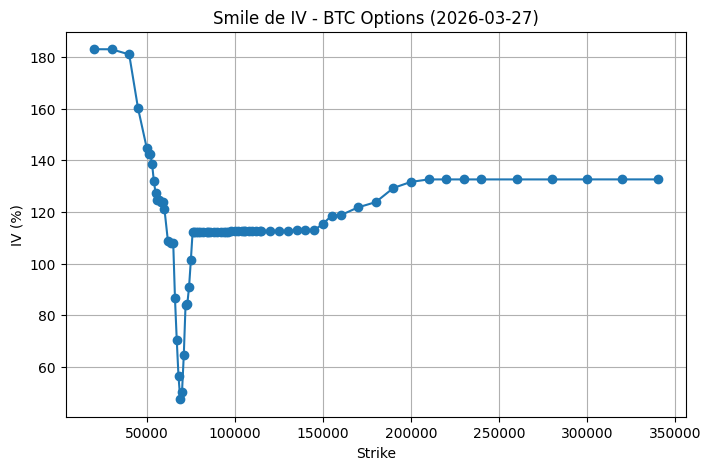

In [171]:
import matplotlib.pyplot as plt

calls = snap_df[snap_df["option_type"] == "call"]

plt.figure(figsize=(8,5))
plt.plot(calls["strike"], calls["iv"], marker='o')
plt.xlabel("Strike")
plt.ylabel("IV (%)")
plt.title(f"Smile de IV - BTC Options ({nearest_expiry.date()})")
plt.grid(True)
plt.show()


smile de volatilidade implícita de um vencimento de BTC na Deribit.

- IV mais alta nos strikes mais baixos (puts OTM → mercado pagando proteção contra queda)

- um vale ali na região mais próxima do ATM (~88k)

- e a IV subindo de novo pros strikes mais altos

Isso é o smile/skew clássico de opções de cripto.

---

# ===================================================
# 1. Criar métricas de skew
# ===================================================

# ===================================================
### Cálculo do skew de volatilidade
# ===================================================

Neste bloco, estimo uma medida simples de **skew de volatilidade** a partir do smile.

A ideia é comparar a volatilidade implícita média de:
- **puts OTM** (strikes abaixo do ATM),
- com a de **calls OTM** (strikes acima do ATM).

Passos do código:
1. Identifico o strike ATM como aquele com menor IV entre as calls.
2. Separo os puts OTM (à esquerda do ATM).
3. Separo os calls OTM (à direita do ATM).
4. Calculo o skew como a diferença entre as IVs médias dos	puts OTM e calls OTM.

No meu caso específico, o resultado foi:

Skew médio ≈ **16.03**

Isso indica que, para esse vencimento, o mercado está atribuindo uma volatilidade implícita significativamente maior para opções de proteção contra queda (puts) do que para calls OTM — ou seja, há um **viés de risco para movimentos de queda**, algo típico em mercados de ativos de risco.

### Pontos ajustáveis

Este cálculo é apenas uma forma simples de medir skew, e pode ser adaptado:

- O critério de ATM pode ser alterado (ex: usar preço spot em vez de IV mínima).
- Em vez de usar todos os puts/calls OTM, pode-se:
  - restringir a faixas específicas de moneyness,
  - usar só opções mais líquidas,
  - ou focar em deltas específicos (ex: 25-delta).
- O skew pode ser redefinido com outras métricas (diferença percentual, regressão, etc.).

Este tipo de medida pode ser usado como feature para análise de regimes de mercado ou complementação do estudo do BVRP, trazendo informação microestrutural do mercado de opções.


In [172]:
atm_strike = calls.loc[calls["iv"].idxmin(), "strike"]

put_otm = snap_df[(snap_df["option_type"] == "put") & (snap_df["strike"] < atm_strike)]
call_otm = snap_df[(snap_df["option_type"] == "call") & (snap_df["strike"] > atm_strike)]

skew = put_otm["iv"].mean() - call_otm["iv"].mean()
print("Skew médio:", skew)


Skew médio: 14.694206349206368


Isso vira uma feature pro ML/regime.

---